In [74]:
# basic imports
import matplotlib.pylab as plt
import numpy as np

# tidy3d imports
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver

In [75]:
# basic parameters (note, all length units are microns)
nm = 1e-3
wavelength = 1550 * nm
freq0 = td.C_0 / wavelength

# waveguide parameters
slot_width = 50 * nm
box_length = 300 * nm
box_height = 180 * nm

# materials
si_med = td.Medium(permittivity=3.48**2)
sub_med = td.Medium(permittivity=1.46**2)

# structures
box1 = td.Structure(
    geometry=td.Box(
        center=(0, -box_length / 2 - slot_width / 2 + 10*nm, -30*nm),
        size=(td.inf, box_length, box_height),
    ),
    medium=si_med,
)
box2 = td.Structure(
    geometry=td.Box(
        center=(0, box_length / 2 + slot_width / 2 - 100 * nm, +30*nm),
        size=(td.inf, box_length, box_height),
    ),
    medium=si_med,
)
sphere = td.Structure(
    geometry=td.Sphere(
        center=(0, 0, -0.1),
        radius=52 * nm,
    ),
    medium=si_med,
)

# boundaries
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

In [76]:
# Plot simulation and overlay grid in the yz and xy planes
def plot_sim_grid(sim):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    sim.plot(x=0, ax=ax[0])
    sim.plot_grid(x=0, ax=ax[0], lw=0.4, colors="r")
    ax[0].set_xlim(-0.6, 0.6)
    ax[0].set_ylim(-0.4, 0.4)
    sim.plot(z=0, ax=ax[1])
    sim.plot_grid(z=0, ax=ax[1], lw=0.4, colors="r")
    ax[1].set_xlim(-0.6, 0.6)
    ax[1].set_ylim(-0.4, 0.4)
    print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.2}")

    return ax


Total number of grid points (millions): 8.3


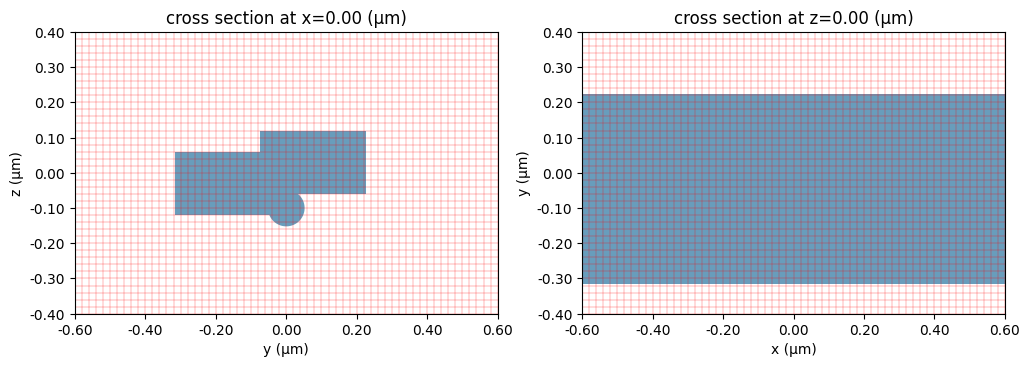

In [77]:
sim_uniform = td.Simulation(
    size=[5, 3, 3],
    center=[0, 0, 0],
    grid_spec=td.GridSpec.uniform(dl=20 * nm),
    medium=sub_med,
    structures=[box1, box2, sphere],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)

ax = plot_sim_grid(sim_uniform)

15:36:05 中国标准时间 WARNING: Override structures should be 'Box' as of        
                      'tidy3d' version 2.8. Given type of '<class               
                      'tidy3d.components.geometry.primitives.Sphere'>, using    
                      '<class                                                   
                      'tidy3d.components.geometry.primitives.Sphere'>.bounding_b
                      ox' instead.                                              

                WARNING: Override structures should be 'Box' as of 'tidy3d'     
                version 2.8. Given type of '<class                              
                'tidy3d.components.geometry.primitives.Sphere'>, using '<class  
                'tidy3d.components.geometry.primitives.Sphere'>.bounding_box'   
                instead.                                                        

                WARNING: Override structures should be 'Box' as of 'tidy3d'     
                version 2.8. Given type of '<class                              
                'tidy3d.components.geometry.primitives.Sphere'>, using '<class  
                'tidy3d.components.geometry.primitives.Sphere'>.bounding_box'   
                instead.                                                        

Total number of grid points (millions): 8.7


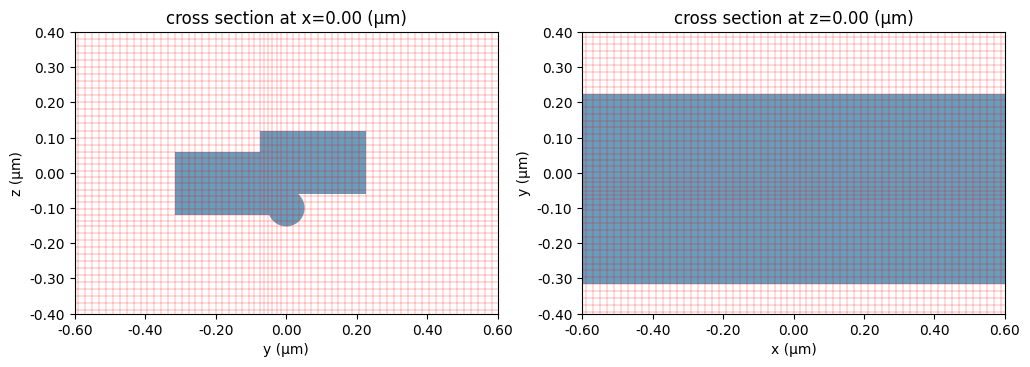

In [78]:
sim_quasiuniform = td.Simulation(
    size=[5, 3, 3],
    grid_spec=td.GridSpec.quasiuniform(dl=20 * nm),
    medium=sub_med,
    structures=[box1, box2, sphere],
    # structures=[box1, box2],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)

ax = plot_sim_grid(sim_quasiuniform)

Total number of grid points (millions): 0.53


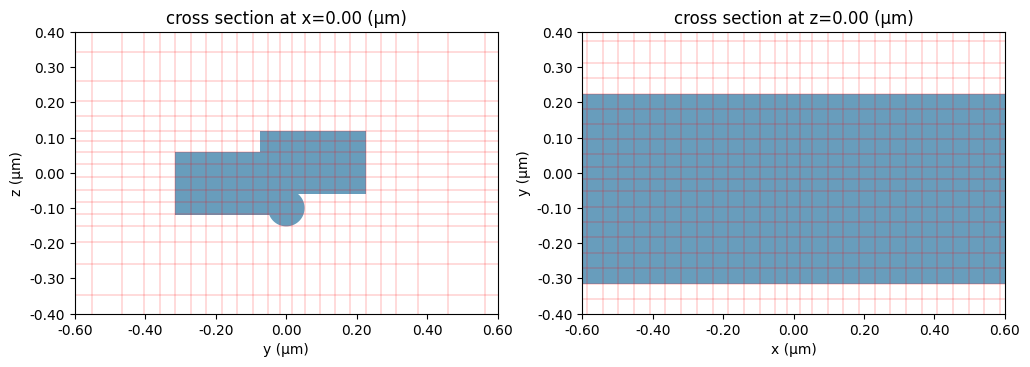

In [79]:
# provide wavelength directly
sim_nonuniform_10 = td.Simulation(
    size=[5, 3, 3],
    grid_spec=td.GridSpec.auto(wavelength=wavelength),
    medium=sub_med,
    structures=[box1, box2],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)

# no grid_spec defined; using default with wavelength taken from source
source = td.ModeSource(
    center=(-2, 0, 0),
    size=(0, 2, 2),
    mode_index=0,
    direction="+",
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
)
sim_nonuniform_10 = td.Simulation(
    size=[5, 3, 3],
    medium=sub_med,
    structures=[box1, box2, sphere],
    boundary_spec=boundary_spec,
    run_time=1e-12,
    sources=[source],
)

ax = plot_sim_grid(sim_nonuniform_10)

Total number of grid points (millions): 2.4


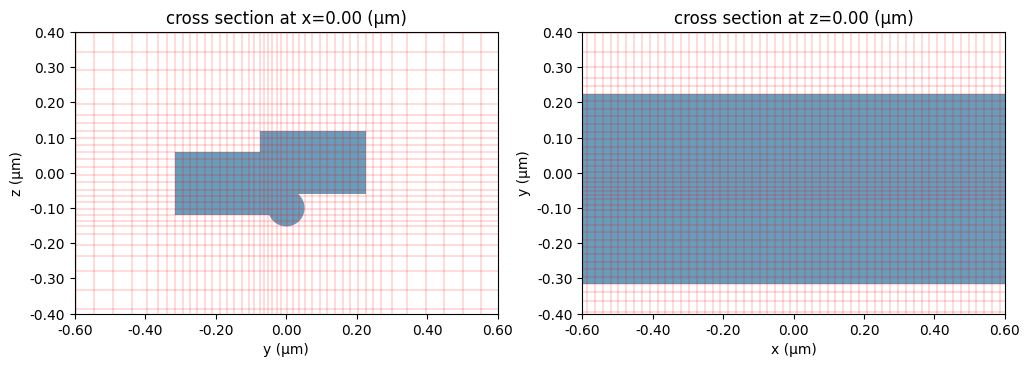

In [80]:
sim_nonuniform_20 = td.Simulation(
    size=[5, 3, 3],
    grid_spec=td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=20,
    ),
    medium=sub_med,
    structures=[box1, box2, sphere],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)
ax = plot_sim_grid(sim_nonuniform_20)

In [81]:
print(f"Minimal grid size along y-direction = {min(sim_nonuniform_20.grid.sizes.y) * 1e3:1.2f}nm")

Minimal grid size along y-direction = 11.50nm


Total number of grid points (millions): 2.0
Minimal grid size along y-direction = 18.50nm


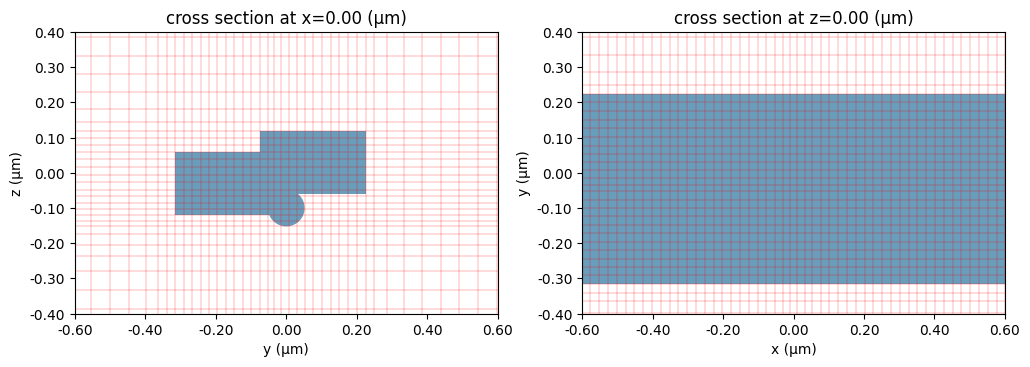

In [73]:
sim_nonuniform_20 = td.Simulation(
    size=[5, 3, 3],
    grid_spec=td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=20,
        dl_min=25 * nm,
    ),
    medium=sub_med,
    structures=[box1, box2, sphere],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)
ax = plot_sim_grid(sim_nonuniform_20)
print(f"Minimal grid size along y-direction = {min(sim_nonuniform_20.grid.sizes.y) * 1e3:1.2f}nm")

Total number of grid points (millions): 2.1


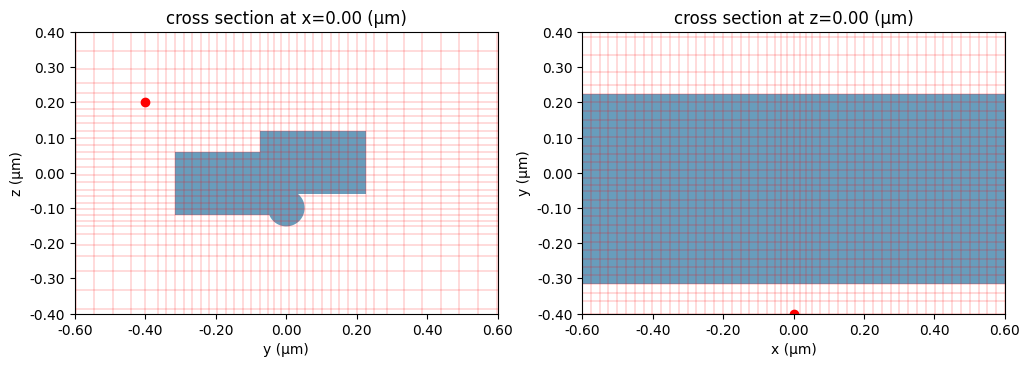

In [72]:
sim_nonuniform_20 = td.Simulation(
    size=[5, 3, 3],
    grid_spec=td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=20,
        dl_min=25 * nm,
        snapping_points=[
            (0, -0.4, 0.2),
        ],
    ),
    medium=sub_med,
    structures=[box1, box2, sphere],
    boundary_spec=boundary_spec,
    run_time=1e-12,
)
ax = plot_sim_grid(sim_nonuniform_20)